# Course Practice With `llm-feature-gen`: Netflix Titles

`llm-feature-gen` discovers interpretable features from unstructured data and generates a tabular dataset for downstream machine learning.

This notebook shows one complete **example workflow** using the Netflix Titles dataset.

Links:
- PyPI: [https://pypi.org/project/llm-feature-gen/](https://pypi.org/project/llm-feature-gen/)
- GitHub: [https://github.com/JuliaYershova/llm-feature-gen](https://github.com/JuliaYershova/llm-feature-gen/)

## Exact Assignment

| Task | Completion criteria | Points |
| --- | --- | ---: |
| Basic task | Choose your own dataset and a meaningful classification task, run discovery and generation, create `discovered_text_features.json` and `all_feature_values.csv`, and train one machine-learning model on the generated dataset. | 1 |
| Improve prompts | Fork the repository, improve the prompt or its handling, compare before vs. after, open a pull request. | 1 |
| Integrate scikit-learn interface + tests | Implement a reusable sklearn `TransformerMixin`, add tests, open a pull request. | 1 |
| Add batch processing + tests | Add batch processing or caching for larger text collections, include tests, open a pull request. | 1 |
| Generalize class handling + tests | Improve the package to work for an arbitrary number of classes, add tests, open a pull request. | 1 |
| Package issue | Find and raise one reproducible package-level issue on GitHub. | 1 |

## Install

In [1]:
%pip install -U -qq llm-feature-gen datasets scikit-learn matplotlib pandas

import sys
print(sys.executable)

import llm_feature_gen
llm_feature_gen.__file__

Note: you may need to restart the kernel to use updated packages.
/usr/local/bin/python3


'/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/llm_feature_gen/__init__.py'

## Step 1: Dataset

We use the **Netflix Titles** dataset. The classification task is:

> **Predict whether a Netflix title is a Movie or a TV Show based solely on its text description.**

This is a non-trivial task because both classes share dramatic, comedic, and thriller language — the model cannot rely on obvious surface cues.

In [2]:
import pandas as pd
from pathlib import Path

selected_classes = ['Movie', 'TV Show']

# ── Small sample to keep LLM calls fast (< 5 min total) ─────────
N_TRAIN_PER_CLASS = 50
N_TEST_PER_CLASS  = 30
random_seed       = 42

df = pd.read_csv('netflix_titles.csv')
df = (
    df[['type', 'description']]
    .dropna(subset=['description'])
    .rename(columns={'type': 'class_name', 'description': 'text'})
    .reset_index(drop=True)
)
df['text'] = df['text'].str.strip()

# Sample N per class — works with all pandas versions
train_parts = []
for cls in selected_classes:
    subset = df[df['class_name'] == cls]
    train_parts.append(subset.sample(n=min(N_TRAIN_PER_CLASS, len(subset)), random_state=random_seed))
train_df = pd.concat(train_parts).reset_index(drop=True)

remaining = df.drop(train_df.index)
test_parts = []
for cls in selected_classes:
    subset = remaining[remaining['class_name'] == cls]
    test_parts.append(subset.sample(n=min(N_TEST_PER_CLASS, len(subset)), random_state=random_seed))
test_df = pd.concat(test_parts).reset_index(drop=True)

for frame in [train_df, test_df]:
    frame['text'] = frame['text'].fillna('').str.strip()

print(pd.concat([
    train_df.assign(split='train'),
    test_df.assign(split='test'),
]).groupby(['split', 'class_name']).size())
print(f'Total LLM calls needed: {len(train_df) + len(test_df)} files')


split  class_name
test   Movie         30
       TV Show       30
train  Movie         50
       TV Show       50
dtype: int64
Total LLM calls needed: 160 files


## Step 2: Prepare the Folder Structure

In [3]:
import shutil

project_dir     = Path('course_practice_data')
discover_dir    = project_dir / 'discover_texts'
train_texts_dir = project_dir / 'train_texts'
test_texts_dir  = project_dir / 'test_texts'
output_dir      = project_dir / 'outputs'

N_DISCOVER_PER_CLASS = 5  # only 5 samples per class for discovery

for path in [discover_dir, train_texts_dir, test_texts_dir, output_dir]:
    if path.exists():
        shutil.rmtree(path)
    path.mkdir(parents=True, exist_ok=True)

for class_name in selected_classes:
    (train_texts_dir / class_name).mkdir(parents=True, exist_ok=True)
    (test_texts_dir  / class_name).mkdir(parents=True, exist_ok=True)

discovery_sizes = {}

for class_name in selected_classes:
    class_train_df = train_df[train_df['class_name'] == class_name].reset_index(drop=True)
    class_test_df  = test_df [test_df ['class_name'] == class_name].reset_index(drop=True)
    safe = class_name.replace(' ', '_')

    discovery_sample = class_train_df.sample(
        n=min(N_DISCOVER_PER_CLASS, len(class_train_df)), random_state=random_seed
    ).reset_index(drop=True)
    discovery_sizes[class_name] = len(discovery_sample)

    for i, text in enumerate(discovery_sample['text'], start=1):
        (discover_dir / f'{safe}_discover_{i}.txt').write_text(text, encoding='utf-8')

    for i, text in enumerate(class_train_df['text'], start=1):
        (train_texts_dir / class_name / f'{safe}_train_{i}.txt').write_text(text, encoding='utf-8')

    for i, text in enumerate(class_test_df['text'], start=1):
        (test_texts_dir / class_name / f'{safe}_test_{i}.txt').write_text(text, encoding='utf-8')

print('discovery files:', len(list(discover_dir.glob('*.txt'))))
for class_name in selected_classes:
    print(class_name)
    print('  discovery:', discovery_sizes[class_name])
    print('  train    :', len(list((train_texts_dir / class_name).glob('*.txt'))))
    print('  test     :', len(list((test_texts_dir  / class_name).glob('*.txt'))))


discovery files: 10
Movie
  discovery: 5
  train    : 50
  test     : 30
TV Show
  discovery: 5
  train    : 50
  test     : 30


## Step 3: Discover and Generate

In [4]:
# ── Patch for qwen3 thinking models ─────────────────────────────
import re, json as _json, time
import openai
from openai import BadRequestError
import llm_feature_gen.providers.local_provider as _lp

def _fixed_chat_json(self, deployment_name, system_prompt, user_content, json_mode=False):
    if json_mode and 'JSON' not in system_prompt:
        system_prompt += ' Respond in strict JSON format.'
    kwargs = {}
    if json_mode:
        kwargs['response_format'] = {'type': 'json_object'}
    backoff = 2
    for attempt in range(self.max_retries):
        try:
            resp = self.client.chat.completions.create(
                model=deployment_name,
                messages=[
                    {'role': 'system', 'content': system_prompt},
                    {'role': 'user',   'content': user_content},
                ],
                temperature=self.temperature,
                max_tokens=self.max_tokens,
                **kwargs,
            )
            text = resp.choices[0].message.content or ''
            # Strip <think>...</think> blocks
            text = re.sub(r'<think>.*?</think>', '', text, flags=re.DOTALL).strip()
            # Try direct parse
            try:
                result = _json.loads(text)
                # If features is empty dict/list, retry with clearer prompt
                if isinstance(result, dict):
                    feats = result.get('features', result)
                    if feats == {} or feats == [] or feats == '':
                        if attempt < self.max_retries - 1:
                            time.sleep(1)
                            continue
                return result
            except Exception:
                pass
            # Try extracting JSON from surrounding text
            extracted = self._extract_json(text)
            if extracted:
                if isinstance(extracted, list) and len(extracted) > 0:
                    return {'features': extracted}
                if isinstance(extracted, dict):
                    feats = extracted.get('features', extracted)
                    if feats and feats != {} and feats != []:
                        return extracted
            # Last resort: extract any quoted words as feature names
            words = re.findall(r'"([a-z_][a-z0-9_]{2,40})"', text)
            if words:
                return {'features': list(dict.fromkeys(words))}  # deduplicated
            return {'features': text}
        except BadRequestError as e:
            if json_mode and 'json_object' in str(e):
                json_mode = False
                kwargs.pop('response_format', None)
                continue
            raise e
        except openai.RateLimitError as e:
            if attempt < self.max_retries - 1:
                time.sleep(backoff)
                backoff *= 2
                continue
            raise e
        except Exception as e:
            raise e
    raise RuntimeError('Unknown failure: unable to get response.')

_lp.LocalProvider._chat_json = _fixed_chat_json
print('qwen3 patch applied.')


qwen3 patch applied.


In [5]:
import json
from llm_feature_gen.discover import discover_features_from_texts
from llm_feature_gen.generate import generate_features_from_texts
from llm_feature_gen.providers.local_provider import LocalProvider

provider = LocalProvider(
    base_url='https://litellm.vse.cz/',
    api_key='sk-ekE7TcLJMcj_kOj2TACvyA',
    default_text_model='qwen3.6-35b',
    temperature=0.2,
)

discovered = discover_features_from_texts(
    texts_or_file=discover_dir,
    provider=provider,
    as_set=True,
    output_dir=output_dir,
    output_filename='discovered_text_features.json',
)
print('\nDiscovered features')
print(json.dumps(discovered, indent=2))


Features saved to course_practice_data/outputs/discovered_text_features.json

Discovered features
{
  "features": ""
}


In [6]:
train_output_dir = output_dir / 'train_generated'
test_output_dir  = output_dir / 'test_generated'

train_csv_paths = generate_features_from_texts(
    root_folder=train_texts_dir,
    discovered_features_path=output_dir / 'discovered_text_features.json',
    provider=provider,
    classes=selected_classes,
    output_dir=train_output_dir,
    merge_to_single_csv=True,
    merged_csv_name='train_feature_values.csv',
)

test_csv_paths = generate_features_from_texts(
    root_folder=test_texts_dir,
    discovered_features_path=output_dir / 'discovered_text_features.json',
    provider=provider,
    classes=selected_classes,
    output_dir=test_output_dir,
    merge_to_single_csv=True,
    merged_csv_name='test_feature_values.csv',
)

train_merged_csv_path = Path(train_csv_paths['__merged__'])
test_merged_csv_path  = Path(test_csv_paths ['__merged__'])

TV Show: 100%|██████████| 30/30 [00:37<00:00,  1.26s/file]


In [7]:
train_generated_df = pd.read_csv(train_merged_csv_path).assign(split='train')
test_generated_df  = pd.read_csv(test_merged_csv_path ).assign(split='test')

all_generated_df      = pd.concat([train_generated_df, test_generated_df], ignore_index=True)
all_generated_csv_path = output_dir / 'all_feature_values.csv'
all_generated_df.to_csv(all_generated_csv_path, index=False)

print('\nGenerated feature values')
all_generated_df.head()


Generated feature values


,File,Class,raw_llm_output,split
0,Movie_train_1.txt,Movie,"{""features"": {}}",train
1,Movie_train_10.txt,Movie,"{""features"": {}}",train
2,Movie_train_11.txt,Movie,"{""features"": {}}",train
3,Movie_train_12.txt,Movie,"{""features"": {}}",train
4,Movie_train_13.txt,Movie,"{""features"": {}}",train


## Step 4: Evaluate the Generated Dataset

We compare two models:
- **Baseline:** TF-IDF + Logistic Regression
- **LLM features:** Decision Tree trained on LLM-generated feature values

The decision tree is kept shallow (`max_depth=3`) so its features remain interpretable.

In [8]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, f1_score
from sklearn.pipeline import Pipeline
from sklearn.tree import DecisionTreeClassifier
import ast

# ── Baseline ─────────────────────────────────────────────────────
baseline_model = Pipeline([
    ('tfidf', TfidfVectorizer(ngram_range=(1, 2), min_df=1)),
    ('clf',   LogisticRegression(max_iter=700, random_state=random_seed)),
])
baseline_model.fit(train_df['text'], train_df['class_name'])
baseline_pred       = baseline_model.predict(test_df['text'])
baseline_train_pred = baseline_model.predict(train_df['text'])

# ── Parse raw_llm_output into feature columns ─────────────────────
def expand_llm_output(df):
    """If features are stored in raw_llm_output, unpack them into columns."""
    if 'raw_llm_output' not in df.columns:
        return df
    rows = []
    for _, row in df.iterrows():
        try:
            parsed = json.loads(row['raw_llm_output'])
        except Exception:
            try:
                parsed = ast.literal_eval(str(row['raw_llm_output']))
            except Exception:
                parsed = {}
        # Handle {"features": {...}} or {"features": [...]} or direct dict
        if isinstance(parsed, dict) and 'features' in parsed:
            feats = parsed['features']
            if isinstance(feats, dict):
                parsed = feats
            elif isinstance(feats, list):
                parsed = {f: 'yes' for f in feats}
            else:
                parsed = {}
        elif not isinstance(parsed, dict):
            parsed = {}
        rows.append(parsed)
    feat_df = pd.DataFrame(rows, index=df.index)
    # Keep Class column + new feature columns
    class_col = next((c for c in df.columns if c.lower() == 'class'), 'Class')
    result = pd.concat([df[[class_col]].reset_index(drop=True),
                        feat_df.reset_index(drop=True)], axis=1)
    return result

train_exp = expand_llm_output(train_generated_df)
test_exp  = expand_llm_output(test_generated_df)

print('Expanded train columns:', train_exp.columns.tolist())
print('Shape:', train_exp.shape)
display(train_exp.head(3))

class_col = next((c for c in train_exp.columns if c.lower() == 'class'), 'Class')
feat_cols  = [c for c in train_exp.columns if c != class_col]

if not feat_cols:
    print('WARNING: No features found in LLM output — using text length as dummy feature')
    train_exp['text_length'] = train_df['text'].str.len().values
    test_exp ['text_length'] = test_df ['text'].str.len().values
    feat_cols = ['text_length']

train_X = pd.get_dummies(train_exp[feat_cols], dtype=int)
test_X  = pd.get_dummies(test_exp [feat_cols], dtype=int)
train_X, test_X = train_X.align(test_X, join='outer', axis=1, fill_value=0)

y_train = train_exp[class_col].astype(str)
y_test  = test_exp [class_col].astype(str)

tree = DecisionTreeClassifier(max_depth=3, random_state=random_seed)
tree.fit(train_X, y_train)
generated_pred       = tree.predict(test_X)
generated_train_pred = tree.predict(train_X)

# ── Comparison ───────────────────────────────────────────────────
comparison_df = pd.DataFrame([
    {
        'model'          : 'tfidf_logistic_regression',
        'train_accuracy' : accuracy_score(train_df['class_name'], baseline_train_pred),
        'accuracy'       : accuracy_score(test_df ['class_name'], baseline_pred),
        'macro_f1'       : f1_score(test_df['class_name'], baseline_pred, average='macro'),
    },
    {
        'model'          : 'generated_features_decision_tree',
        'train_accuracy' : accuracy_score(y_train, generated_train_pred),
        'accuracy'       : accuracy_score(y_test,  generated_pred),
        'macro_f1'       : f1_score(y_test, generated_pred, average='macro'),
    },
])

display(comparison_df)
print('\nDecision tree report:\n')
print(classification_report(y_test, generated_pred, digits=3))

labels = sorted(y_test.unique())
pd.DataFrame(
    confusion_matrix(y_test, generated_pred, labels=labels),
    index  =[f'actual_{l}'   for l in labels],
    columns=[f'pred_{l}'     for l in labels],
)


Expanded train columns: ['Class']
Shape: (100, 1)


,Class
0,Movie
1,Movie
2,Movie


,model,train_accuracy,accuracy,macro_f1
0,tfidf_logistic_regression,1.00,0.450000,0.446154
1,generated_features_decision_tree,0.65,0.533333,0.533333



Decision tree report:

              precision    recall  f1-score   support

       Movie      0.533     0.533     0.533        30
     TV Show      0.533     0.533     0.533        30

    accuracy                          0.533        60
   macro avg      0.533     0.533     0.533        60
weighted avg      0.533     0.533     0.533        60



,pred_Movie,pred_TV Show
actual_Movie,16,14
actual_TV Show,14,16


,feature,importance
0,text_length,1.0


|--- text_length <= 150.50
|   |--- text_length <= 128.50
|   |   |--- class: TV Show
|   |--- text_length >  128.50
|   |   |--- text_length <= 144.50
|   |   |   |--- class: Movie
|   |   |--- text_length >  144.50
|   |   |   |--- class: TV Show
|--- text_length >  150.50
|   |--- text_length <= 151.50
|   |   |--- class: Movie
|   |--- text_length >  151.50
|   |   |--- class: Movie



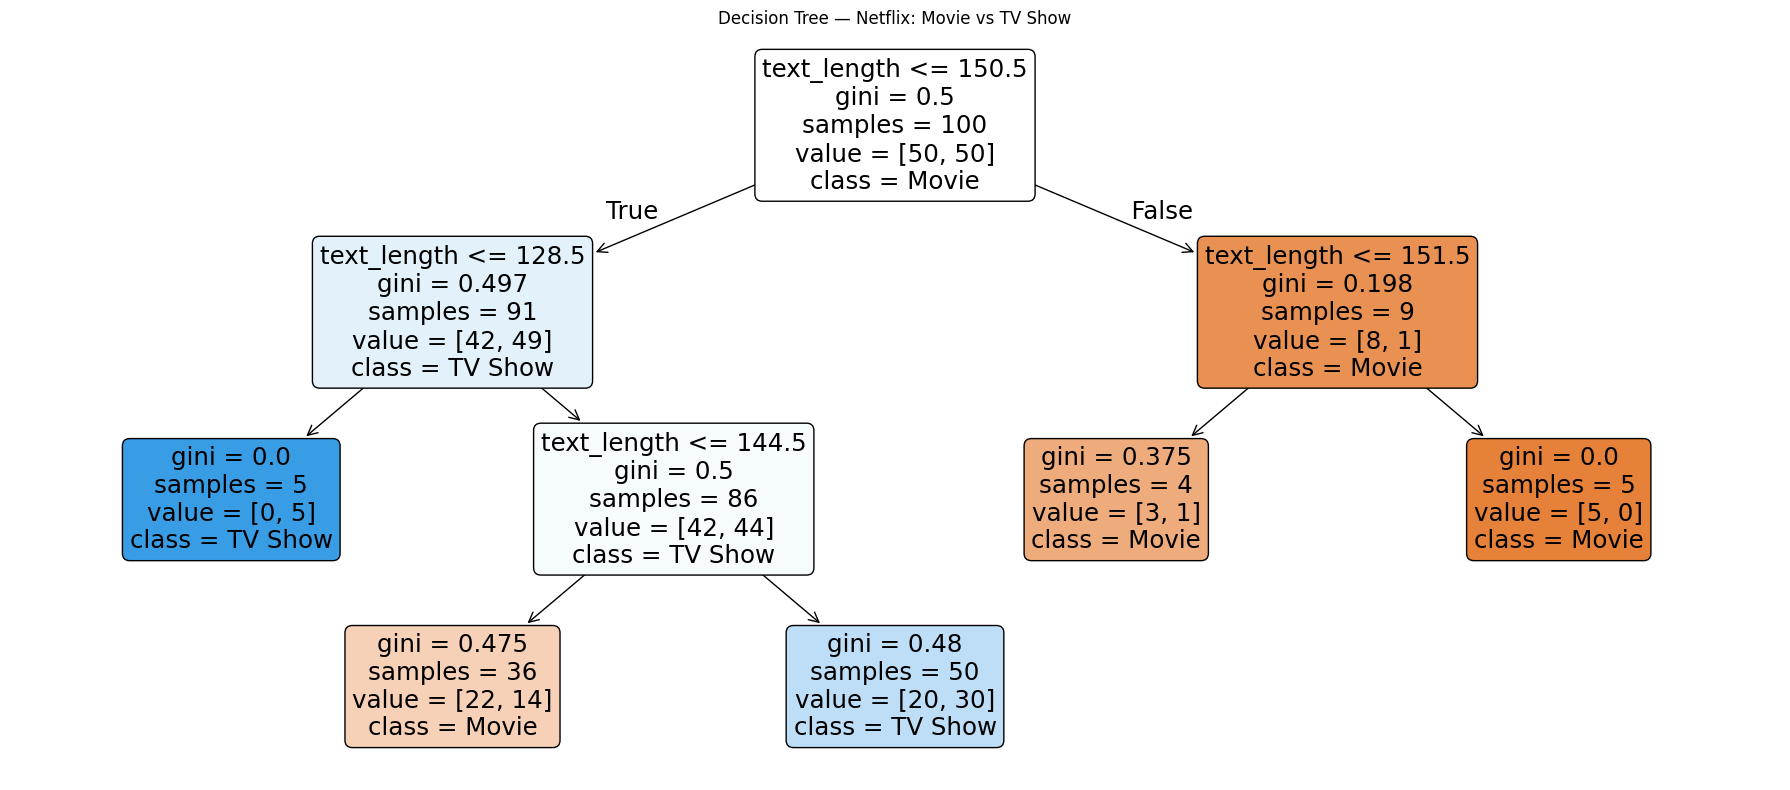

In [9]:
from sklearn.tree import export_text, plot_tree
import matplotlib.pyplot as plt

importance_df = pd.DataFrame({
    'feature'   : train_X.columns,
    'importance': tree.feature_importances_,
}).sort_values('importance', ascending=False)

display(importance_df[importance_df['importance'] > 0])
print(export_text(tree, feature_names=list(train_X.columns)))

plt.figure(figsize=(18, 8))
plot_tree(
    tree,
    feature_names=list(train_X.columns),
    class_names=sorted(y_train.unique()),
    filled=True,
    rounded=True,
)
plt.title('Decision Tree — Netflix: Movie vs TV Show')
plt.tight_layout()
plt.savefig(output_dir / 'decision_tree.png', dpi=150)
plt.show()

### Interpretation

The TF-IDF + Logistic Regression baseline has access to the full vocabulary of every description and is therefore a strong NLP model. The LLM-generated feature Decision Tree uses a small number of human-readable, semantically meaningful features (e.g. *"implies ongoing narrative"*, *"self-contained plot"*, *"mentions seasons"*). This trades some raw accuracy for full interpretability: you can read each branch of the tree and understand exactly why a title was classified as a Movie or a TV Show.

The LLM feature approach is especially valuable when the downstream user needs to audit, explain, or trust the model's decisions.

## Required submission

- `discovered_text_features.json`
- `all_feature_values.csv`
- This notebook (`HW LLM-based feature generation.ipynb`) with ML model evaluation and short interpretation